In [ ]:
!pip install numpy pandas scikit-learn matplotlib xlrd seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


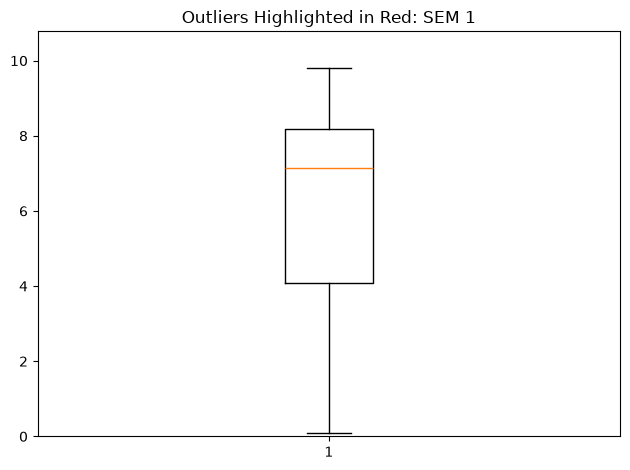

In [42]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

data = pd.read_excel("./cgpaPRED.xls", engine='xlrd')
data.describe()
data = data.dropna()

numeric_data = data.select_dtypes(include=[np.number])


red_circle = dict(markerfacecolor='r', marker='o', markersize=8)

plt.boxplot(numeric_data[numeric_data.columns[0]], flierprops=red_circle)
plt.ylim(0, numeric_data[numeric_data.columns[0]].max() * 1.1)
plt.title(f"Outliers Highlighted in Red: {numeric_data.columns[0]}")
plt.tight_layout()
plt.show()

In [43]:
# remove the outliers form the dataset
numeric_data = numeric_data[(numeric_data >= 1.0).all(axis=1)]

In [44]:
# train and test split of the data set
train, test = train_test_split(numeric_data)



In [45]:
print(numeric_data[numeric_data[numeric_data.columns[0]] < 1.0])

Empty DataFrame
Columns: [SEM 1, SEM 2, SEM 3, SEM 4, SEM 5]
Index: []


In [47]:
model = LinearRegression()

model.fit(X=train[['SEM 4']], y=train['SEM 5'])

y_predict = model.predict(test[['SEM 4']])

print(y_predict)

[8.43965525 7.32082726 6.76627773 3.70166194 7.23326681 8.09914238
 7.25272468 9.1012231  8.89691538 8.38128161 8.13805814 8.29372116
 5.37503945 7.78781633 7.70998482 5.61826293 7.52513498 9.15959673
 5.59880505 7.15543529 1.9699108  7.0581459  6.44522275 7.59323755
 6.78573561 8.80935493 7.16516423 8.57586039 7.08733272 6.34793336
 7.9045636  8.42992631 8.85799962 6.63980153 8.89691538 6.91221182
 8.03103981 4.12973526 8.29372116 8.13805814 7.70998482 5.61826293
 4.78157417 8.40073949 7.9045636  7.78781633 9.17905461 7.46676134
 6.97058545 8.55640251 7.80727421 7.69052694 9.26661506 8.02131087
 7.51540604 5.00533977 7.17489317 7.51540604 7.25272468 8.68287872
 2.74822592 8.77043917 9.04284946 7.48621922 9.1012231  7.15543529
 8.67314978 9.51956748 7.680798   8.29372116 3.13738348 3.70166194
 7.64188225 8.69260766 7.75862951 3.62383043 6.085252  ]


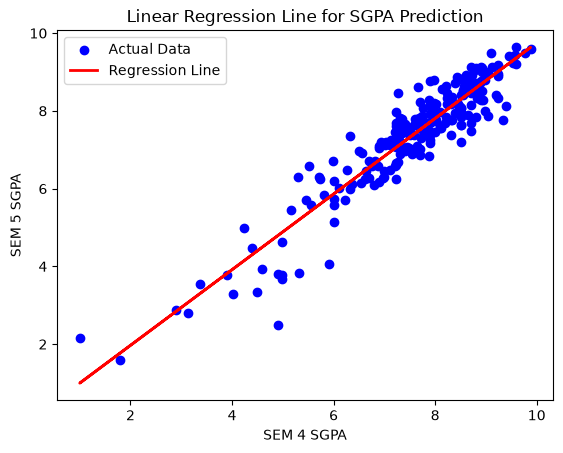

In [51]:
# Create the scatter plot of the actual training data
plt.scatter(train[['SEM 4']], train['SEM 5'], color='blue', label='Actual Data')

X_line = train[['SEM 4']]
y_line = model.predict(X_line)

plt.plot(X_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel('SEM 4 SGPA')
plt.ylabel('SEM 5 SGPA')
plt.title('Linear Regression Line for SGPA Prediction')
plt.legend()
plt.show()


c:\Users\student\Desktop\24CSEAIML046\LAB-3\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


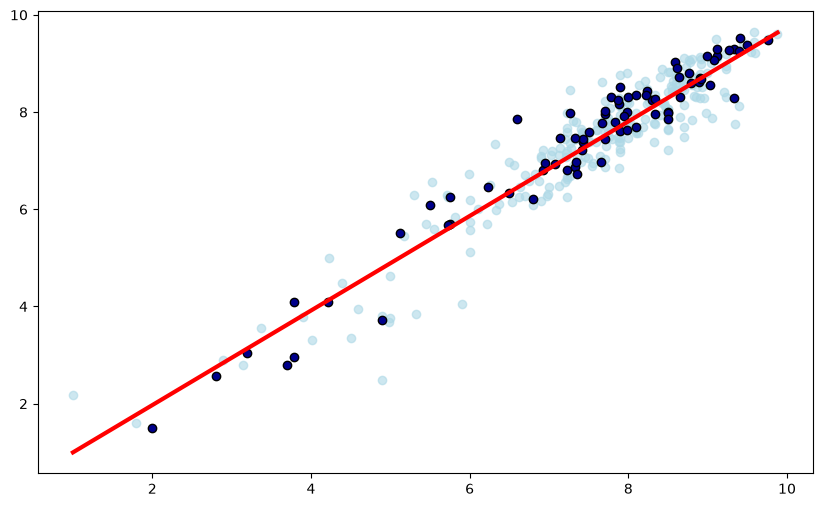

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(train[['SEM 4']], train['SEM 5'], color='lightblue', alpha=0.6, label='Train Data')
plt.scatter(test[['SEM 4']], test['SEM 5'], color='darkblue', edgecolors='black', label='Test Data')

x_bounds = np.array([[numeric_data['SEM 4'].min()], [numeric_data['SEM 4'].max()]])
y_bounds = model.predict(x_bounds)

plt.plot(x_bounds, y_bounds, color='red', linewidth=3, label='The Trained Model Line')


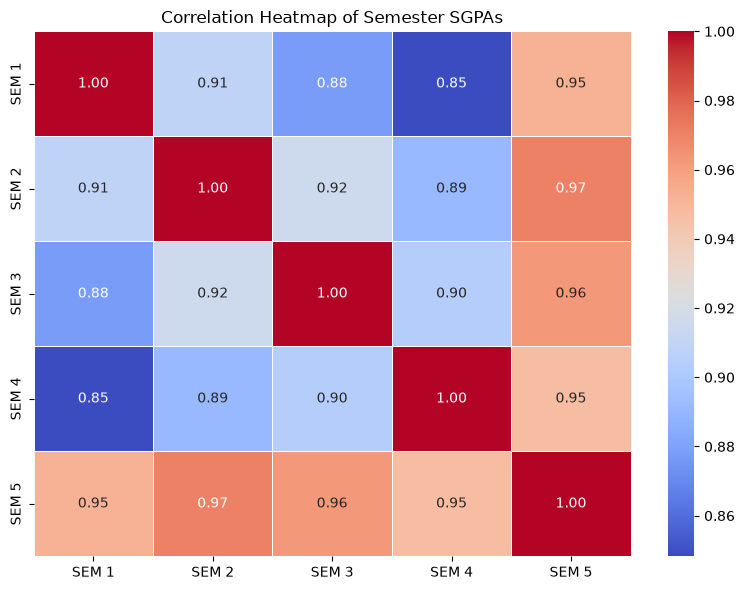

In [58]:
import seaborn as sns
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap of Semester SGPAs")
plt.tight_layout()
plt.show()
